### Assignment

Objective of the assignment is to explore the relationship between trader performance and market sentiment, uncover hidden patterns and deliver insights that can drive smarter trading strategies.
Link to dataset
- Historical Data :https://drive.google.com/file/d/1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs/view?usp=sharing
- Fear Greed Index link:https://drive.google.com/file/d/1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf/view?usp=sharing

#### Importing important libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Import the Dataset as Pandas DataFrame

In [3]:
fear_df = pd.read_csv("data/fear_greed_index.csv")
trade_df = pd.read_csv("data/historical_data.csv")

#### Showing top 5 record of imported dataset

In [4]:
fear_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trade_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


#### Exploring dataset

In [8]:
fear_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [9]:
fear_df.isna().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [6]:
trade_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [7]:
trade_df.isna().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

#### Checking number of unique value for each row

In [11]:
fear_df.nunique()

timestamp         2644
value               90
classification       5
date              2644
dtype: int64

In [12]:
trade_df.nunique()

Account                 32
Coin                   246
Execution Price      60162
Size Tokens          59304
Size USD            118493
Side                     2
Timestamp IST        27977
Start Position      196923
Direction               12
Closed PnL           90720
Transaction Hash    101184
Order ID             50555
Crossed                  2
Fee                 138802
Trade ID              2810
Timestamp                7
dtype: int64

#### Convert Date in both dataframe in proper Datatime format

In [13]:
fear_df["date"] = pd.to_datetime(fear_df["date"])

In [16]:
trade_df["Timestamp IST"] = pd.to_datetime(
    trade_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)
trade_df["date"] = trade_df["Timestamp IST"].dt.date
trade_df["date"] = pd.to_datetime(trade_df["date"])

#### Understanding the sentiment

In [17]:
fear_df["classification"].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

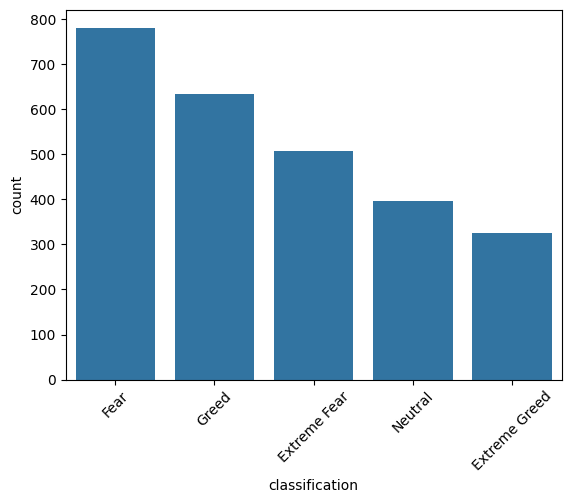

In [18]:
sns.countplot(
    data=fear_df,
    x="classification",
    order=fear_df["classification"].value_counts().index
)

plt.xticks(rotation=45)
plt.show()

#### Merging of two dataset

In [19]:
merged_df = trade_df.merge(
    fear_df[["date","value","classification"]],
    on="date",
    how="left"
)

In [20]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [21]:
merged_df["classification"].isna().sum()

np.int64(6)

Above 6 indicate out of total trades 6 rows couldnt find matching data for its sentiments. Since 6 is a very low number compared to volume we have so it would be better to delete those record.

In [22]:
merged_df = merged_df.dropna(subset=["classification"])

In [23]:
merged_df["classification"].isna().sum()

np.int64(0)

In [24]:
merged_df.info()

<class 'pandas.DataFrame'>
Index: 211218 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211218 non-null  str           
 1   Coin              211218 non-null  str           
 2   Execution Price   211218 non-null  float64       
 3   Size Tokens       211218 non-null  float64       
 4   Size USD          211218 non-null  float64       
 5   Side              211218 non-null  str           
 6   Timestamp IST     211218 non-null  datetime64[us]
 7   Start Position    211218 non-null  float64       
 8   Direction         211218 non-null  str           
 9   Closed PnL        211218 non-null  float64       
 10  Transaction Hash  211218 non-null  str           
 11  Order ID          211218 non-null  int64         
 12  Crossed           211218 non-null  bool          
 13  Fee               211218 non-null  float64       
 14  Trade ID          21

#### Classification of features

In [25]:
numerical_cols = merged_df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = merged_df.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

datetime_cols = merged_df.select_dtypes(
    include=['datetime64[ns]']
).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\nDatetime Columns:")
print(datetime_cols)

Numerical Columns:
['Execution Price', 'Size Tokens', 'Size USD', 'Start Position', 'Closed PnL', 'Order ID', 'Fee', 'Trade ID', 'Timestamp', 'value']

Categorical Columns:
['Account', 'Coin', 'Side', 'Direction', 'Transaction Hash', 'Crossed', 'classification']

Datetime Columns:
['Timestamp IST', 'date']


C:\Users\anike\AppData\Local\Temp\ipykernel_5596\681890066.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = merged_df.select_dtypes(


In [28]:
merged_df[numerical_cols].describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,211218.000000,2.112180e+05,2.112180e+05,2.112180e+05,211218.000000,2.112180e+05,211218.000000,2.112180e+05,2.112180e+05,211218.000000
mean,11415.047529,4.623341e+03,5.639192e+03,-2.994671e+04,48.549304,6.965470e+10,1.163960,5.628506e+14,1.737745e+12,51.649656
std,29448.010305,1.042744e+05,3.657557e+04,6.738170e+05,917.989791,1.835714e+10,6.758948,3.257541e+14,8.689946e+09,21.012784
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.858550,2.940000e+00,1.937900e+02,-3.760725e+02,0.000000,5.984223e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970200e+02,8.477051e+01,0.000000,7.442939e+10,0.089572,5.620000e+14,1.740000e+12,49.000000
75%,101.895000,1.878900e+02,2.058878e+03,9.337697e+03,5.790132,8.335543e+10,0.393774,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000


In [31]:
for col in categorical_cols:
    print(f"\n{col}")
    print(merged_df[col].value_counts().head())


Account
Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
Name: count, dtype: int64

Coin
Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
Name: count, dtype: int64

Side
Side
SELL    108528
BUY     102690
Name: count, dtype: int64

Direction
Direction
Open Long      49895
Close Long     48678
Open Short     39741
Close Short    36007
Sell           19902
Name: count, dtype: int64

Transaction Hash
Transaction Hash
0x0000000000000000000000000000000000000000000000000000000000000000    9032
0x8543ffeb4fdab50bfa0304222f29b702012700b5ee6b85c21ed9215e3bc8ba45     298
0xb3a9e6e4f5293d501bb3041f5c49ec02018b00ecdfb8798414bcd103222f2c30     247
0xa67acabfc24d0cb5d05b041f1704590204f000525423d8cded7ec70825f7b658     240
0x6b313e029807198fba0f04215de94801ac

#### Create useful features

In [32]:
merged_df["win"] = merged_df["Closed PnL"] > 0

In [33]:
merged_df["trade_result"] = merged_df["Closed PnL"].apply(
    lambda x: "Profit" if x > 0 else "Loss"
)

In [34]:
merged_df["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

#### Visualize the sentiments

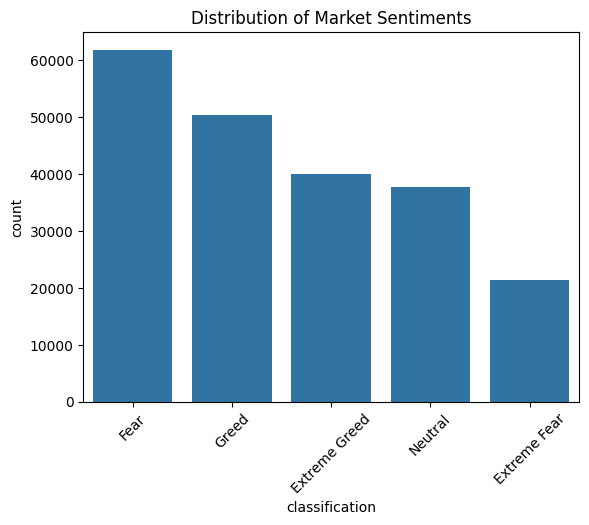

In [35]:
sns.countplot(
    data=merged_df,
    x="classification",
    order=merged_df["classification"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Distribution of Market Sentiments")
plt.show()

#### Average Profit and Loss vs Sentiments

In [36]:
avg_pnl = (
    merged_df.groupby("classification")
    ["Closed PnL"]
    .mean()
    .sort_values()
)

avg_pnl

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64

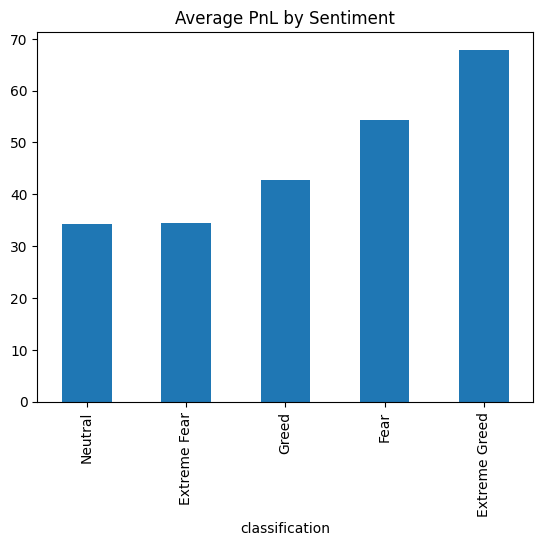

In [37]:
avg_pnl.plot(kind="bar")
plt.title("Average PnL by Sentiment")
plt.show()

#### Where is the most money made in accordance to sentiments

In [38]:
total_pnl = (
    merged_df.groupby("classification")
    ["Closed PnL"]
    .sum()
)

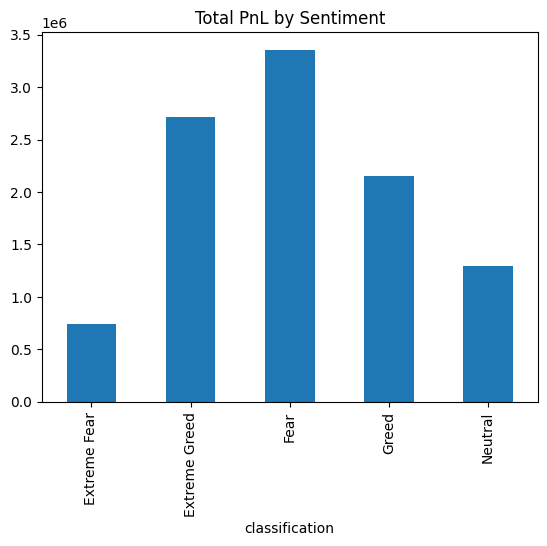

In [39]:
total_pnl.plot(kind="bar")
plt.title("Total PnL by Sentiment")
plt.show()

#### Win rate by sentiments

In [40]:
win_rate = (
    merged_df.groupby("classification")
    ["win"]
    .mean()
    * 100
)

win_rate

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64

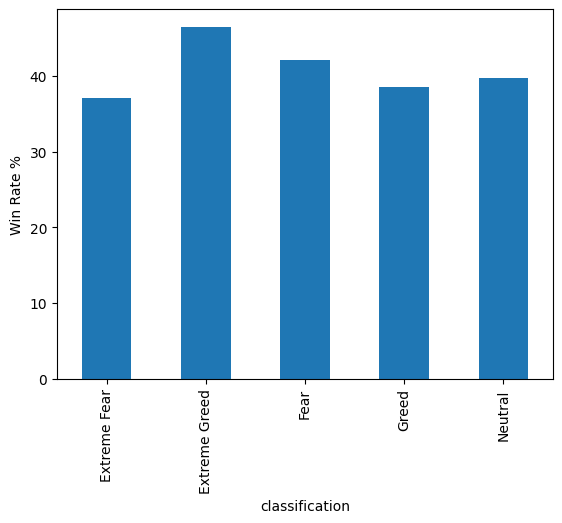

In [41]:
win_rate.plot(kind="bar")
plt.ylabel("Win Rate %")
plt.show()

#### Trading activity analysis

In [42]:
trade_count = (
    merged_df.groupby("classification")
    .size()
)

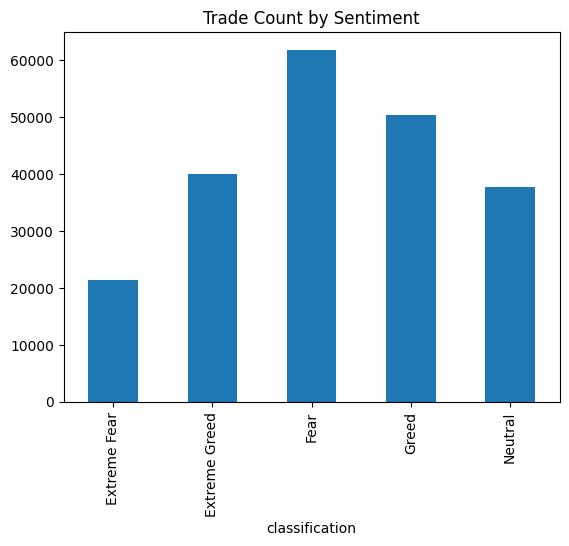

In [43]:
trade_count.plot(kind="bar")
plt.title("Trade Count by Sentiment")
plt.show()

#### Buy and sell behaviour

In [44]:
buy_sell = pd.crosstab(
    merged_df["classification"],
    merged_df["Side"]
)

buy_sell

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


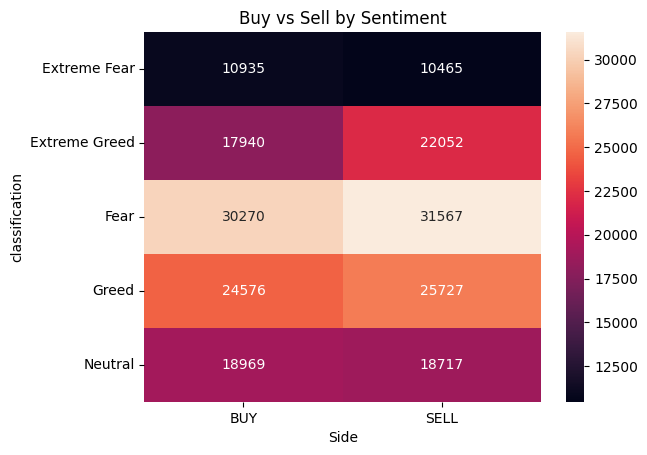

In [45]:
sns.heatmap(
    buy_sell,
    annot=True,
    fmt="d"
)

plt.title("Buy vs Sell by Sentiment")
plt.show()

#### Top 10 traders

In [50]:
top_traders = (
    merged_df.groupby("Account")
    ["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
)

top_traders.head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64

<Axes: xlabel='Account'>

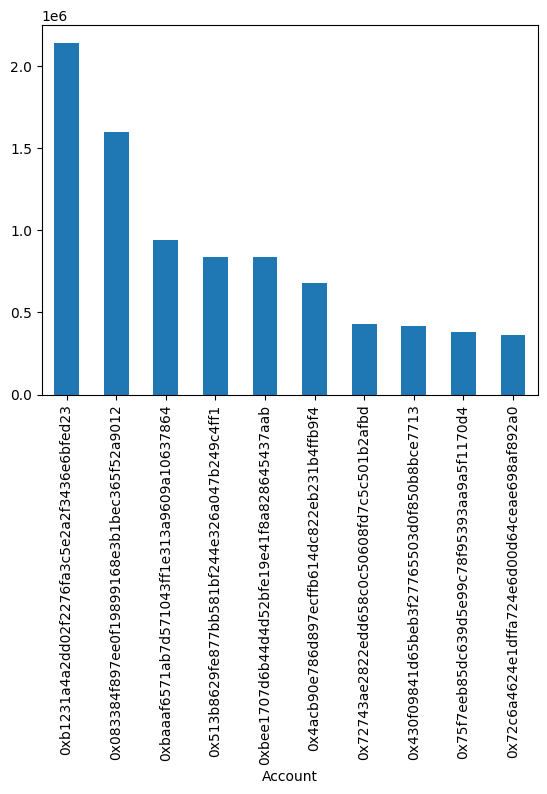

In [51]:
top_traders.head(10).plot(
    kind="bar"
)

#### Bottom 10 traders

In [52]:
top_traders.tail(10)

Account
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     53496.247243
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     47885.320514
0x8477e447846c758f5a675856001ea72298fd9cb5     43917.008976
0xb899e522b5715391ae1d4f137653e7906c5e2115     22488.500821
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     21758.831753
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
Name: Closed PnL, dtype: float64

In [53]:
account_sentiment = pd.pivot_table(
    merged_df,
    values="Closed PnL",
    index="Account",
    columns="classification",
    aggfunc="sum"
)

account_sentiment

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
Account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,124769.221441,-4.028234e+04,1.113374e+06,276719.270187,125650.116740
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,-4235.153051,3.565889e+04,-1.658737e+03,30053.395556,-11933.080125
0x271b280974205ca63b716753467d5a371de622ab,16706.884912,1.793160e+03,3.012191e+04,-100019.806374,-19038.340561
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,-25666.012284,1.080100e+05,1.342252e+04,31192.591971,5505.749364
0x2c229d22b100a7beb69122eed721cee9b24011dd,11415.247787,9.089505e+04,3.979191e+03,20075.672949,42292.843076
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-56967.825773,3.099218e+04,-4.670589e+02,-3531.989984,-1228.907104
0x39cef799f8b69da1995852eea189df24eb5cae3c,-76179.494853,1.440638e+04,5.468502e+04,10591.760255,10953.247960
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,110.553364,3.687016e+04,4.256559e+03,4239.816383,8019.163096
0x420ab45e0bd8863569a5efbb9c05d91f40624641,9461.082288,4.019619e+03,9.964828e+04,12082.950000,74293.663505


In [54]:
numeric_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Start Position",
    "Closed PnL",
    "Fee",
    "value"
]

#### Coorelation analysis of numerical features

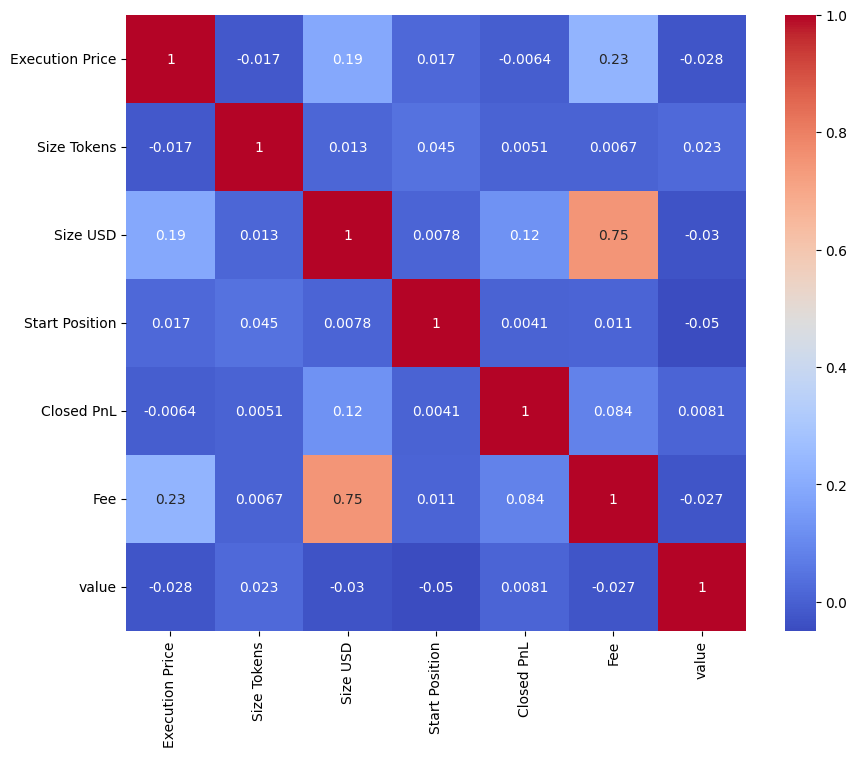

In [55]:
plt.figure(figsize=(10,8))

sns.heatmap(
    merged_df[numeric_cols]
    .corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

#### Conclusion

This analysis explored the relationship between Market sentiments and trader performance in accordance to that sentiments.
After understanding the available dataset and merging them, several patterns and insights could be inferred regarding traders behaviour, profitability and activity under various market condition.

Key findings are as follows:
- Fear was the most dominant market sentiment throughout the trading period.
- Extreme Greed generated the highest average profit per trade.
- Extreme Fear recorded the lowest win rate, indicating difficult trading conditions.
- Sell orders slightly outnumbered Buy orders across all market conditions.
- Trade size and transaction fees exhibited a strong positive relationship.
- Sentiment score alone showed minimal direct correlation with individual trade profitability.
- Both sentiment and trading activity jointly influenced overall profitability patterns.

#### Thanking you